Assignment Task:
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.
Dataset Description:
The dataset consists of the following variables:
Age: Age in years
KM: Accumulated Kilometers on odometer
FuelType: Fuel Type (Petrol, Diesel, CNG)
HP: Horse Power
Automatic: Automatic ( (Yes=1, No=0)
CC: Cylinder Volume in cubic centimeters
Doors: Number of doors
Weight: Weight in Kilograms
Quarterly_Tax: 
Price: Offer Price in EUROs
Tasks:
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.
4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.
5.Apply Lasso and Ridge methods on the model.

Interview Questions:
1.What is Normalization & Standardization and how is it helpful?
2.What techniques can be used to address multicollinearity in multiple linear regression?


Ensure to properly comment your code and provide explanations for your analysis.
Include any assumptions made during the analysis and discuss their implications.

1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("ToyotaCorolla_-_MLR[1].csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.shape

(1436, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [7]:
df.isnull().sum

<bound method DataFrame.sum of       Price  Age_08_04     KM  Fuel_Type     HP  Automatic     cc  Doors  \
0     False      False  False      False  False      False  False  False   
1     False      False  False      False  False      False  False  False   
2     False      False  False      False  False      False  False  False   
3     False      False  False      False  False      False  False  False   
4     False      False  False      False  False      False  False  False   
...     ...        ...    ...        ...    ...        ...    ...    ...   
1431  False      False  False      False  False      False  False  False   
1432  False      False  False      False  False      False  False  False   
1433  False      False  False      False  False      False  False  False   
1434  False      False  False      False  False      False  False  False   
1435  False      False  False      False  False      False  False  False   

      Cylinders  Gears  Weight  
0         False  False 

In [10]:
df.duplicated().sum()

np.int64(1)

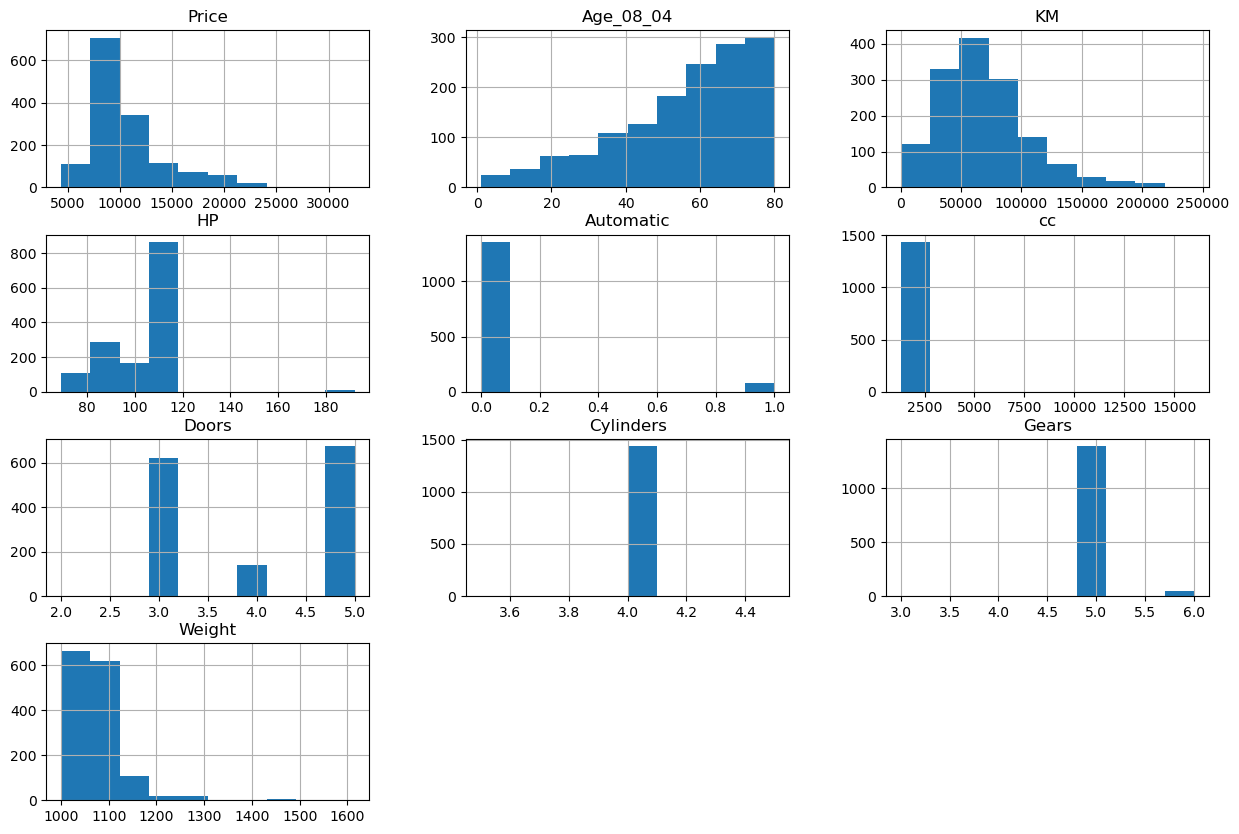

In [11]:
df.hist(figsize=(15,10))
plt.show()

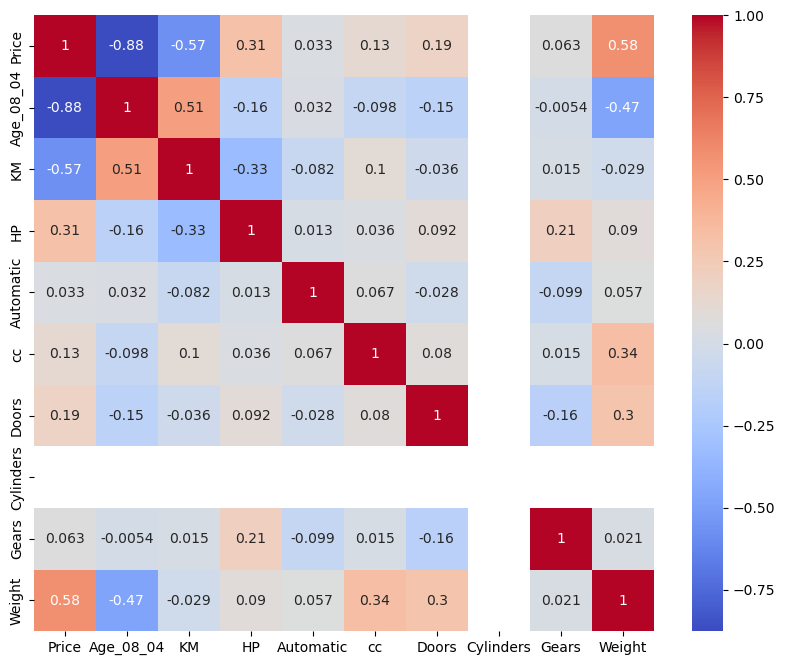

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

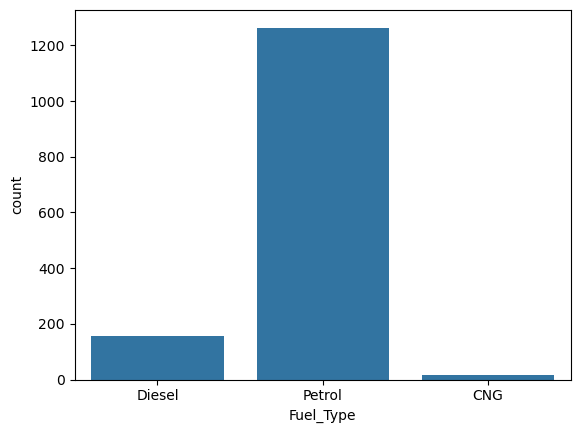

In [13]:
sns.countplot(x="Fuel_Type", data=df)
plt.show()

In [14]:
df["Fuel_Type"] = df["Fuel_Type"].map({
    "Petrol": 0,
    "Diesel": 1,
    "CNG": 2
})

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170


In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

print(X.head())
print(y.head())

   Age_08_04     KM  Fuel_Type  HP  Automatic    cc  Doors  Cylinders  Gears  \
0         23  46986          1  90          0  2000      3          4      5   
1         23  72937          1  90          0  2000      3          4      5   
2         24  41711          1  90          0  2000      3          4      5   
3         26  48000          1  90          0  2000      3          4      5   
4         30  38500          1  90          0  2000      3          4      5   

   Weight  
0    1165  
1    1165  
2    1165  
3    1165  
4    1170  
0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64


2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1148, 10)
X_test shape: (288, 10)
y_train shape: (1148,)
y_test shape: (288,)


3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

1  LINEAR REGRESSION Model Create & Train

In [18]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [20]:
y_pred1 = model1.predict(X_test)
print(y_pred1[:10])

[11176.88365168  8969.1938439   9390.64915234  8959.94241825
 10094.01821299  7913.49724682  8711.31021617  8272.4299364
 14099.45852336 13127.72764197]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, y_pred1))
print("MSE :", mean_squared_error(y_test, y_pred1))
print("R2 Score :", r2_score(y_test, y_pred1))

Linear Regression Results
MAE : 992.8982858371405
MSE : 2096851.1400177006
R2 Score : 0.8428476112018004


2 Ridge Regression

In [22]:
from sklearn.linear_model import Ridge
model2 = Ridge(alpha=1.0)
model2.fit(X_train, y_train)
print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [23]:
y_pred2 = model2.predict(X_test)
print(y_pred2[:10])

[11178.96976821  8969.87052323  9391.87949289  8960.18445671
 10094.57458657  7912.67597771  8712.52430498  8274.31151433
 14099.63694964 13128.46921848]


In [24]:
print("Ridge Regression Results")
print("MAE :", mean_absolute_error(y_test, y_pred2))
print("MSE :", mean_squared_error(y_test, y_pred2))
print("R2 Score :", r2_score(y_test, y_pred2))

Ridge Regression Results
MAE : 992.8742553506735
MSE : 2095305.8178633808
R2 Score : 0.842963428230191


3 Lasso Model Train

In [25]:
from sklearn.linear_model import Lasso
model3 = Lasso(alpha=1.0)
model3.fit(X_train, y_train)
print("Lasso Regression Model Trained Successfully!")

Lasso Regression Model Trained Successfully!


In [26]:
y_pred3 = model3.predict(X_test)
print(y_pred3[:10])

[11180.0226119   8971.30668737  9392.57685708  8962.68057595
 10097.1515656   7915.1953282   8714.35355533  8276.57634551
 14100.94423241 13130.55854757]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Lasso Regression Results")
print("MAE :", mean_absolute_error(y_test, y_pred3))
print("MSE :", mean_squared_error(y_test, y_pred3))
print("R2 Score :", r2_score(y_test, y_pred3))

Lasso Regression Results
MAE : 992.9143095869032
MSE : 2095598.6166041833
R2 Score : 0.8429414838867533


4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [28]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MAE": [
        mean_absolute_error(y_test, y_pred1),
        mean_absolute_error(y_test, y_pred2),
        mean_absolute_error(y_test, y_pred3)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred1),
        mean_squared_error(y_test, y_pred2),
        mean_squared_error(y_test, y_pred3)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred1),
        r2_score(y_test, y_pred2),
        r2_score(y_test, y_pred3)
    ]
})

print(results)

               Model         MAE           MSE  R2 Score
0  Linear Regression  992.898286  2.096851e+06  0.842848
1   Ridge Regression  992.874255  2.095306e+06  0.842963
2   Lasso Regression  992.914310  2.095599e+06  0.842941


5.Apply Lasso and Ridge methods on the model.

In [29]:
print("Ridge Regression R2 Score :", r2_score(y_test, y_pred2))
print("Lasso Regression R2 Score :", r2_score(y_test, y_pred3))

Ridge Regression R2 Score : 0.842963428230191
Lasso Regression R2 Score : 0.8429414838867533


In [30]:
print("Ridge Regression")
print("MAE :", mean_absolute_error(y_test, y_pred2))
print("R2 Score :", r2_score(y_test, y_pred2))
print()
print("Lasso Regression")
print("MAE :", mean_absolute_error(y_test, y_pred3))
print("R2 Score :", r2_score(y_test, y_pred3))

Ridge Regression
MAE : 992.8742553506735
R2 Score : 0.842963428230191

Lasso Regression
MAE : 992.9143095869032
R2 Score : 0.8429414838867533


Interview Questions:


1.What is Normalization & Standardization and how is it helpful?

Normalization scales the data between 0 and 1.
Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1.

-It is helpful because:
-It improves model performance.
-It speeds up model training.
-It ensures all features contribute equally.
-It helps algorithms converge faster.

2.What techniques can be used to address multicollinearity in multiple linear regression?

-Remove highly correlated features.
-Use Ridge Regression.
-Use Lasso Regression.
-Check Variance Inflation Factor (VIF).
-Apply Principal Component Analysis (PCA).

## Analysis

The dataset was analyzed using Multiple Linear Regression. Linear Regression, Ridge Regression, and Lasso Regression models were trained and evaluated using MAE, MSE, and R² Score. The models achieved similar performance.

## Assumptions

- The dataset has no missing values.
- Features have a linear relationship with the target variable.
- The data is split into 80% training and 20% testing.